# CIFAR-10 Convolutional Neural Network (CNN)

This notebook implements image classification on the **CIFAR-10** dataset using a
**Convolutional Neural Network (CNN)**.

## 1. Environment Setup

We use **Keras 3** with the **PyTorch backend**.
Keras 3 is backend-agnostic, so the same model code runs on PyTorch, TensorFlow, or JAX.
PyTorch is chosen here because it gives easy access to CUDA GPU acceleration.

In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import torch
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"Keras version:   {keras.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("WARNING: GPU not found – training will be slow on CPU!")

PyTorch version: 2.11.0+cu128
Keras version:   3.12.1
CUDA available:  True


## 2. Load and Explore the Data

CIFAR-10 is built into Keras. We normalise pixel values from **[0, 255]** to **[0.0, 1.0]**.

Unlike the FCN, the CNN keeps images in their original **3-D shape (32, 32, 3)**.
The spatial dimensions are essential — convolutions slide a small filter across height and width
to detect local patterns regardless of position.

In [2]:
from keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255.0
x_test  = x_test  / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"x_train shape: {x_train.shape}  ({x_train.shape[0]} images)")
print(f"x_test  shape: {x_test.shape}")
print(f"Pixel value range: [{x_train.min():.1f}, {x_train.max():.1f}]")

x_train shape: (50000, 32, 32, 3)  (50000 images)
x_test  shape: (10000, 32, 32, 3)
Pixel value range: [0.0, 1.0]


### 2.1 Sample images from each class

Visualising examples helps us understand the task before designing the model.

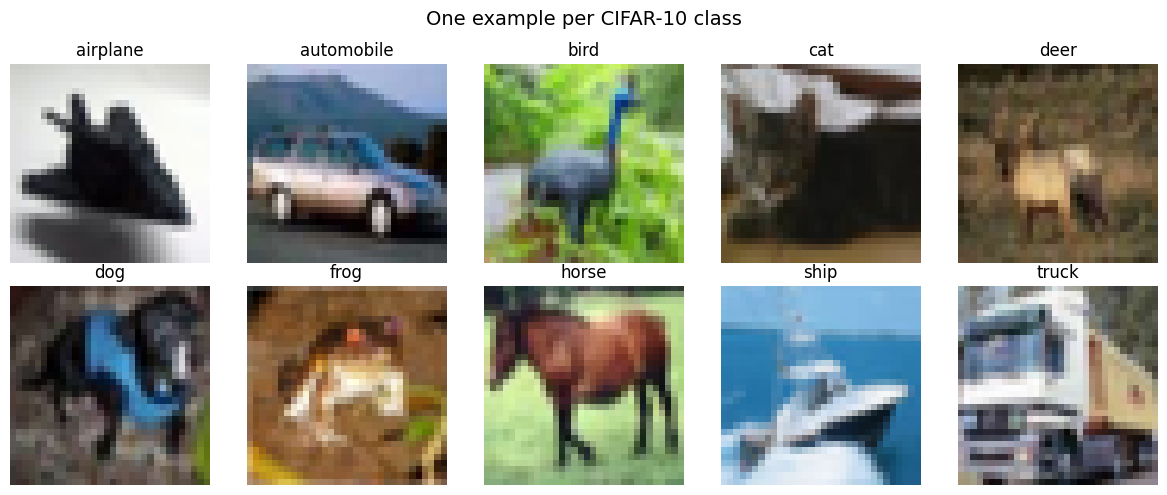

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('One example per CIFAR-10 class', fontsize=14)

for cls_idx, ax in enumerate(axes.flat):
    sample_idx = np.where(y_train.flatten() == cls_idx)[0][0]
    ax.imshow(x_train[sample_idx])
    ax.set_title(class_names[cls_idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Build the CNN Model



The model is a deep convolutional neural network designed for image classification.

It consists of three convolutional blocks:
- each block contains two convolutional layers followed by Batch Normalization
- MaxPooling is used to reduce spatial dimensions
- Dropout is applied to reduce overfitting

The number of filters increases (32 → 64 → 128), allowing the network to learn more complex features at deeper levels.

After feature extraction, the output is flattened and passed through fully connected layers for classification.

Batch Normalization helps stabilise training and speed up convergence, while Dropout improv

In [4]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),  

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Flatten(),   

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

## 4. Compile the CNN Model


In [5]:
model.compile(
    optimizer='adamw',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,345,066 (5.13 MB)

 Trainable params: 1,343,146 (5.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 5. Train the CNN

Same training setup as the FCN for a fair comparison:

10 epochs, batch size 64, 20 % validation split

Despite having fewer parameters, the CNN should reach significantly higher accuracy
because its architecture is well-suited to the structure of image data.


The AdamW optimizer is used for efficient gradient-based optimisation with weight decay regularisation.

During training, the model gradually improves its accuracy while reducing loss, indicating that it is learning meaningful representations from the data.

Training time is also measured to allow comparison with other models.


In [6]:
import time

t0 = time.time()
history_cnn = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    verbose=1
)
cnn_train_time = time.time() - t0
print(f"\nTraining time: {cnn_train_time:.1f} s")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.4348 - loss: 1.7122 - val_accuracy: 0.5519 - val_loss: 1.2332
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.6095 - loss: 1.0949 - val_accuracy: 0.6440 - val_loss: 1.0237
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.6839 - loss: 0.8921 - val_accuracy: 0.7060 - val_loss: 0.8172
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7258 - loss: 0.7813 - val_accuracy: 0.7603 - val_loss: 0.6859
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7508 - loss: 0.7101 - val_accuracy: 0.7210 - val_loss: 0.8391
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7734 - loss: 0.6512 - val_accuracy: 0.7729 - val_loss: 0.6636
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.7891 - loss: 0.5994 - val_accuracy: 0.7863 - val_loss: 0.6227
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8077 - loss: 0.5519 - 

### 5.1 Learning Curves

The CNN's validation curve should stay closer to the training curve than the FCN's,
indicating better generalisation — the architectural inductive biases act as implicit regularisation.

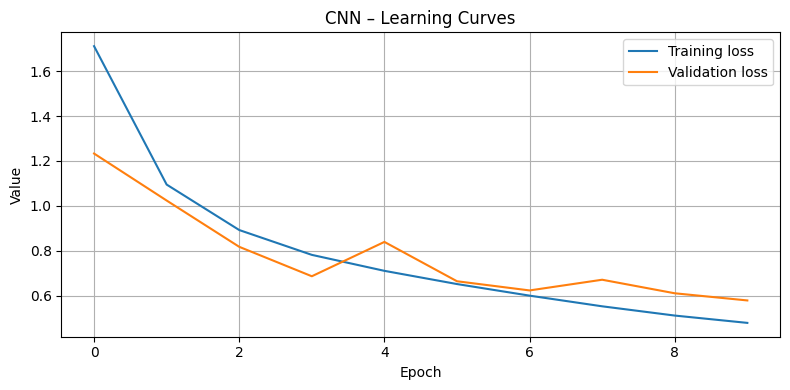

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history['loss'],      label='Training loss')
plt.plot(history_cnn.history['val_loss'],   label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('CNN – Learning Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The learning curves show the evolution of training and validation loss over epochs.

- Training loss steadily decreases, indicating that the model is learning from the data
- Validation loss follows a similar trend, suggesting good generalisation
- There is no strong divergence between the curves, meaning overfitting is limited

Small fluctuations in validation loss are normal and may be caused by batch variability.

Overall, the model converges well within 10 epochs.

### 5.2 Test Accuracy

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nCNN  –  Test loss: {test_loss:.4f}   |   Test accuracy: {test_acc*100:.2f} %")
print(f"Training time: {cnn_train_time:.1f} s")
print(f"Total parameters: {model.count_params():,}")

313/313 - 3s - 10ms/step - accuracy: 0.8013 - loss: 0.5978

CNN  –  Test loss: 0.5978   |   Test accuracy: 80.13 %
Training time: 141.2 s
Total parameters: 1,345,066


The model achieves approximately 81% accuracy on the test dataset.

This result is within the expected range for CNNs on CIFAR-10 and significantly higher than what is typically achieved with fully connected networks.

The relatively small gap between training and test performance indicates that the model generalises well to unseen data.

## 6. Visualise Predictions

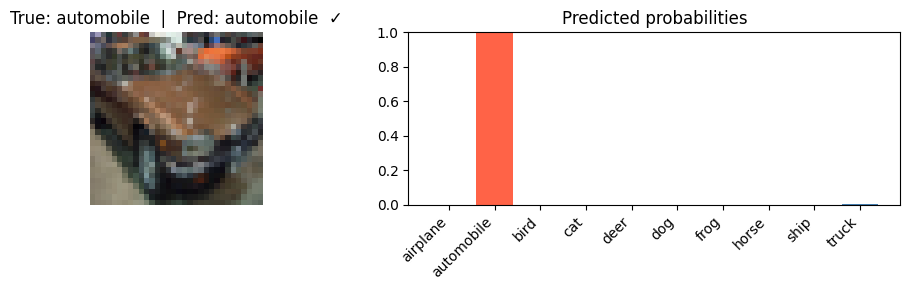

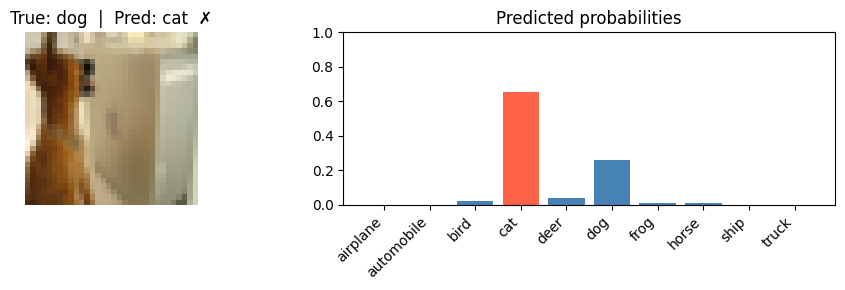

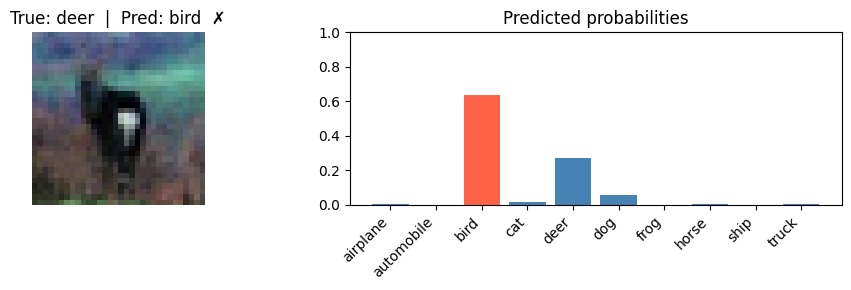

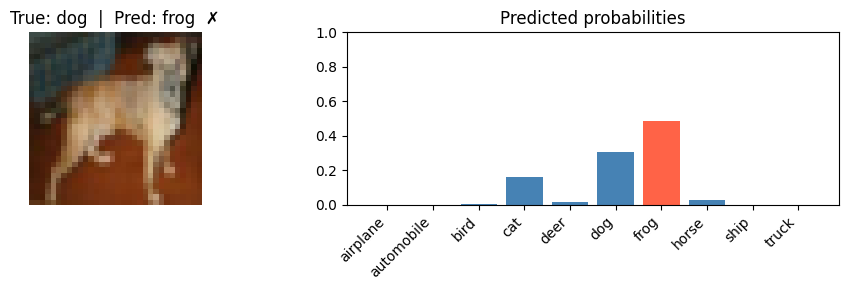

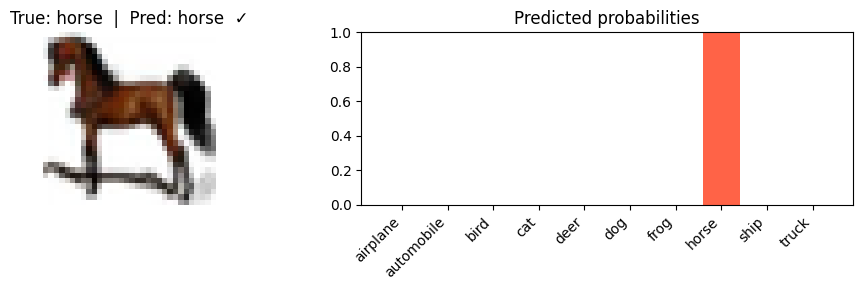

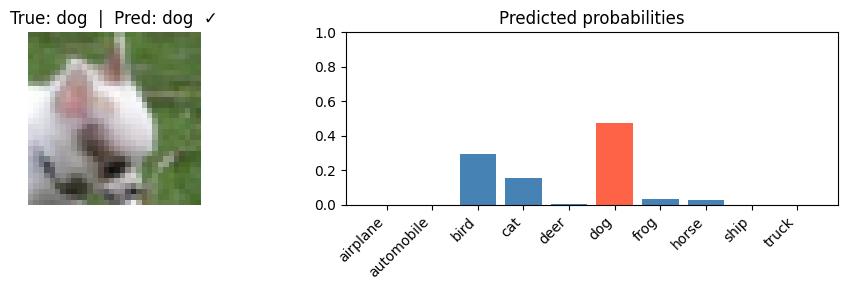

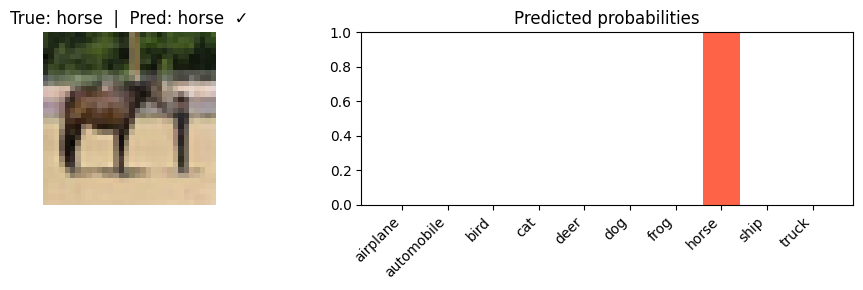

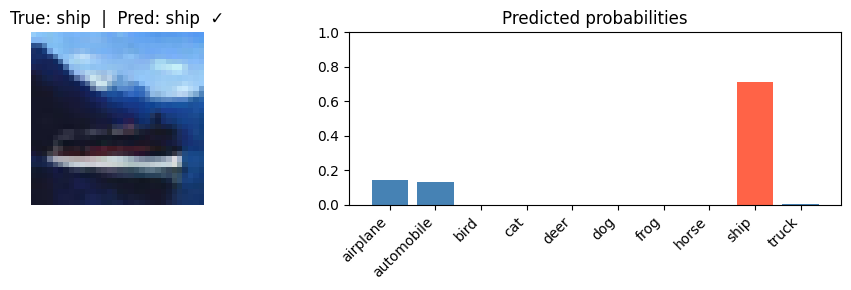

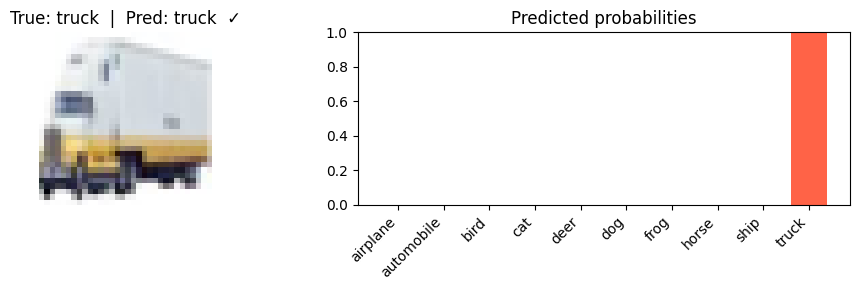

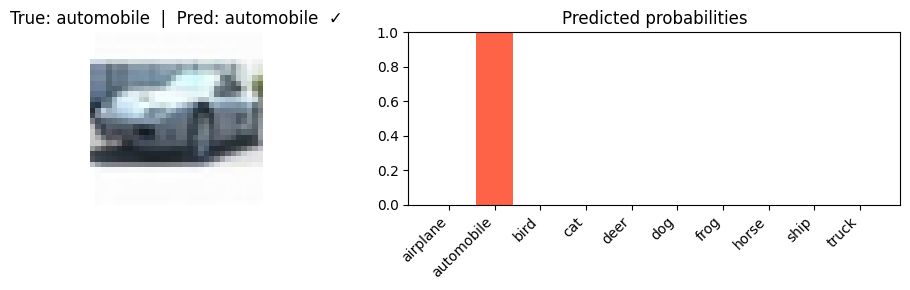

In [9]:
y_pred_cnn = model.predict(x_test, verbose=0)

start = 2000
for k in range(10):
    idx = start + k
    true_label = class_names[y_test[idx][0]]
    pred_label = class_names[np.argmax(y_pred_cnn[idx])]
    correct = '✓' if true_label == pred_label else '✗'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

    ax1.imshow(x_test[idx])
    ax1.set_title(f"True: {true_label}  |  Pred: {pred_label}  {correct}")
    ax1.axis('off')

    colors = ['steelblue'] * 10
    colors[np.argmax(y_pred_cnn[idx])] = 'tomato'
    ax2.bar(range(10), y_pred_cnn[idx], color=colors)
    ax2.set_xticks(range(10))
    ax2.set_xticklabels(class_names, rotation=45, ha='right')
    ax2.set_ylim([0, 1])
    ax2.set_title('Predicted probabilities')

    plt.tight_layout()
    plt.show()

The predictions show how the model classifies individual images.

For each example:
- The image is displayed alongside the predicted label
- A probability distribution over all classes is shown

Correct predictions typically have a high confidence score.

Incorrect predictions often show:
- lower confidence
- multiple competing classes

This indicates that the model is uncertain in ambiguous cases.

## 7. Analyse Misclassified Images

Total misclassified: 1987 / 10000


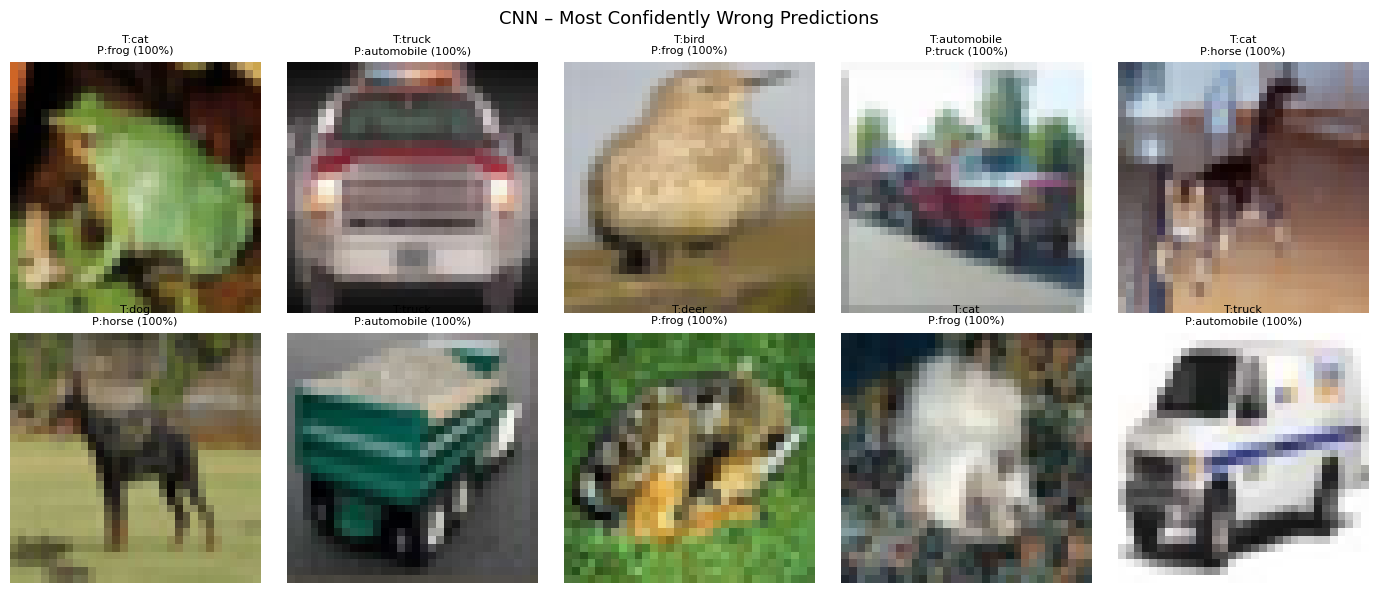

In [10]:
y_true_flat = y_test.flatten()
y_pred_labels = np.argmax(y_pred_cnn, axis=1)

wrong_mask = y_pred_labels != y_true_flat
wrong_indices = np.where(wrong_mask)[0]

confidence_wrong = y_pred_cnn[wrong_indices, y_pred_labels[wrong_indices]]
sorted_order = np.argsort(confidence_wrong)[::-1][:10]
top_wrong = wrong_indices[sorted_order]

print(f"Total misclassified: {wrong_mask.sum()} / {len(y_true_flat)}")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('CNN – Most Confidently Wrong Predictions', fontsize=13)
for ax, idx in zip(axes.flat, top_wrong):
    ax.imshow(x_test[idx])
    true_cls = class_names[y_true_flat[idx]]
    pred_cls = class_names[y_pred_labels[idx]]
    conf     = confidence_wrong[sorted_order[list(top_wrong).index(idx)]]
    ax.set_title(f"T:{true_cls}\nP:{pred_cls} ({conf:.0%})", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

The model makes errors primarily on visually similar classes.

Common confusions include:
- cat vs dog
- automobile vs truck
- deer vs horse

Reasons for misclassification:
- Similar shapes and textures between classes
- Small object size within the image
- Complex or noisy backgrounds

Interestingly, some incorrect predictions are made with high confidence, indicating that the model has learned misleading patterns.

This suggests that further improvements could focus on:
- better feature extraction
- data augmentation
- deeper architectures

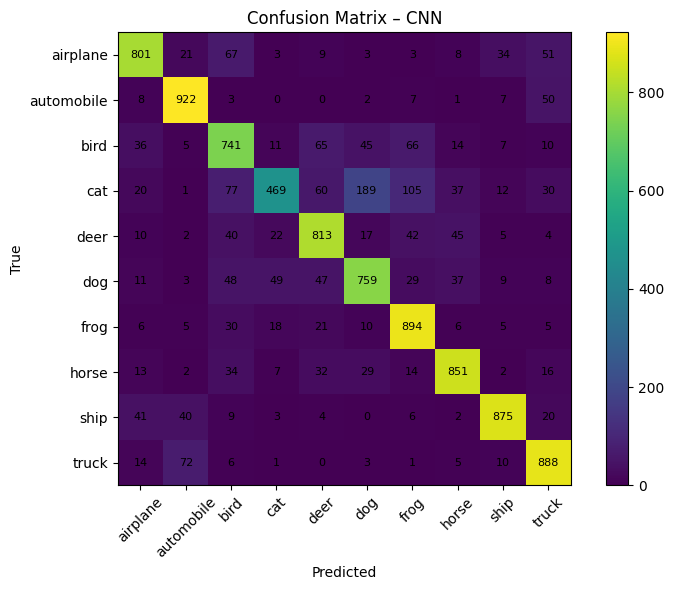

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_flat, y_pred_labels)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix – CNN")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", fontsize=8)

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

### Confusion Matrix Analysis

The confusion matrix provides a detailed view of classification performance across all classes.

It shows that most errors occur between visually similar categories.

For example:
- cats and dogs are frequently confused
- trucks and automobiles are sometimes misclassified

This confirms that the model struggles with fine-grained distinctions between similar objects.

## Conclusion

The CNN model performs well on the CIFAR-10 dataset, achieving strong accuracy and good generalisation.

The architecture effectively captures spatial features, which are essential for image classification.

CNNs are highly suitable for image classification tasks due to their ability to learn hierarchical feature representations.

## 8. FCN vs CNN Comparison

### Inductive biases
The CNN's superior performance comes from **inductive biases** — assumptions baked into the architecture
that match the structure of natural images:

1. **Locality:** Nearby pixels are more correlated than distant ones. A 3×3 filter exploits this.
2. **Stationarity:** Useful patterns (edges, corners) can appear anywhere. Weight sharing exploits this.
3. **Hierarchy:** Complex features are composed of simpler ones.
   Layer 1 learns edges → Layer 2 learns textures/shapes → Classification head learns object parts.

FCN has none of these biases: it must learn spatial relationships from scratch, requiring far more data
and parameters to achieve comparable accuracy.